Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout,Input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("results", exist_ok=True)

ModuleNotFoundError: No module named 'keras'

Load Dataset

In [ ]:
dataset=pd.read_csv("dataset/heart.csv")
dataset.head(5)

,age,sex,smoke,years,ldl,chp,height,weight,fh,active,...,ihd,hr,dm,bpsys,bpdias,htn,ivsd,ecgpatt,qwave,target
0,65,0,0,0,69.0,4,168,111.0,1,0,...,1,98,1,120,80,1,0,4,0,0
1,54,1,0,0,117.0,2,145,81.0,0,0,...,0,85,0,130,80,0,0,4,0,0
2,61,0,1,45,86.2,2,160,72.0,0,0,...,0,63,1,150,70,1,0,2,0,1
3,57,0,0,0,76.0,2,176,78.0,1,0,...,1,74,1,120,70,0,0,3,0,1
4,62,1,0,0,160.0,3,154,61.0,0,0,...,0,89,1,110,70,0,0,1,0,1


Check the null Value

In [5]:
dataset.isnull().sum()

age          0
sex          0
smoke        0
years        0
ldl          0
chp          0
height       0
weight       0
fh           0
active       0
lifestyle    0
ihd          0
hr           0
dm           0
bpsys        0
bpdias       0
htn          0
ivsd         0
ecgpatt      0
qwave        0
target       0
dtype: int64

Split X and y

In [6]:
X=dataset.drop('target',axis=1)
y=dataset['target']


Train and Test Split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


Using Scale Method

In [8]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)


ANN Model

Adding input layer and hidden layers

In [9]:
classifier= Sequential()
classifier.add(Input(shape=(X_train.shape[1],)))   
classifier.add(Dense(16, activation='relu'))
classifier.add(Dense(8, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(1, activation='sigmoid'))

Compile the ANN

In [10]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Fitting the ANN

In [11]:
classifier.fit(x_train_scaled,y_train,epochs=50,batch_size=16,validation_split=0.2)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3962 - loss: 0.8777 - val_accuracy: 0.4630 - val_loss: 0.8282
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5047 - loss: 0.8020 - val_accuracy: 0.5000 - val_loss: 0.7762
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4670 - loss: 0.7815 - val_accuracy: 0.5000 - val_loss: 0.7374
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5519 - loss: 0.7023 - val_accuracy: 0.5556 - val_loss: 0.7067
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6085 - loss: 0.6812 - val_accuracy: 0.5926 - val_loss: 0.6807
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6226 - loss: 0.6707 - val_accuracy: 0.6481 - val_loss: 0.6594
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6557 - loss: 0.6009 - val_accuracy: 0.6667 - val_loss: 0.6399
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7028 - loss: 0.5995 - val_accuracy: 0.7037 - val_lo

Accuracy

In [12]:
accuracy = classifier.evaluate(x_test_scaled, y_test)
print("Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8358 - loss: 0.4345
Accuracy: [0.4345402419567108, 0.8358209133148193]


Predict the test result

In [13]:
y_pred = classifier.predict(x_test_scaled) 
y_pred=(y_pred>0.5)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

Confusion matrix and Classification report

In [14]:
confusion_matrics_result=confusion_matrix(y_test,y_pred)
print("Confusion Matrix\n",confusion_matrics_result)
print("Classification Report\n",classification_report(y_test, y_pred))


Confusion Matrix
 [[31  7]
 [ 4 25]]
Classification Report
               precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.78      0.86      0.82        29

    accuracy                           0.84        67
   macro avg       0.83      0.84      0.83        67
weighted avg       0.84      0.84      0.84        67



Confusion Matrix Heatmap

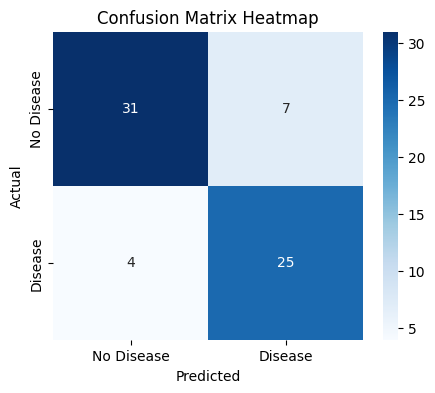

In [15]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrics_result, annot=True, fmt='d', cmap='Blues',xticklabels=['No Disease', 'Disease'],yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

ROC-AUC

In [16]:
roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc)

ROC-AUC: 0.8389292196007259


Plot for accuracy

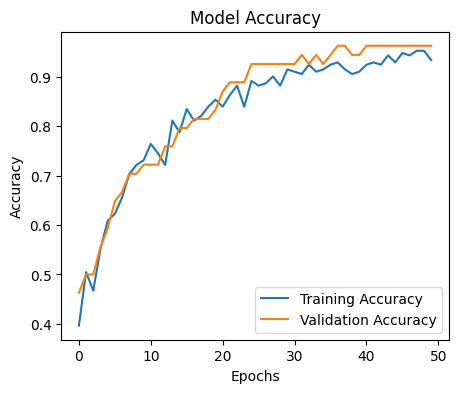

In [17]:
plt.figure(figsize=(5,4))
plt.plot(classifier.history.history['accuracy'], label='Training Accuracy')
plt.plot(classifier.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
loss, accuracy = classifier.evaluate(x_test_scaled, y_test)

with open("results/accuracy.txt", "w") as f:
    f.write(f"Loss: {loss}\n")
    f.write(f"Accuracy: {accuracy}\n")

print("Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8358 - loss: 0.4345
Accuracy: 0.8358209133148193


In [19]:
import pandas as pd

y_pred = classifier.predict(x_test_scaled)
y_pred = (y_pred > 0.5)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

results_df.to_csv("results/predictions.csv", index=False)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

confusion_matrics_result = confusion_matrix(y_test, y_pred)

with open("results/report.txt", "w") as f:
    f.write("Confusion Matrix:\n")
    f.write(str(confusion_matrics_result))
    f.write("\n\nClassification Report:\n")
    f.write(classification_report(y_test, y_pred))

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrics_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')

plt.savefig("results/confusion_matrix_pic.png")  
plt.close()

In [22]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_pred)

with open("results/roc_auc.txt", "a") as f:
    f.write(f"ROC-AUC: {roc}\n")

print("ROC-AUC:", roc)

ROC-AUC: 0.8389292196007259


In [23]:
plt.figure(figsize=(5,4))
plt.plot(classifier.history.history['accuracy'], label='Training Accuracy')
plt.plot(classifier.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("results/accuracy_graph.png")  # SAVE
plt.close()

In [24]:
classifier.save("results/model.h5")